Importing relevant libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
#import Axes3D for some of the 3D visualisation
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D

from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Reading the file

In [2]:
data=pd.read_csv('tracksProcessed.csv')
data

,Unnamed: 0,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,release_year
0,39511,6Pkt6qVikqPBt9bEQy8iTz,A Lover's Concerto,41,159560,0,The Toys,6lH5PpuiMa5SpfjoIOlwCS,2020-03-13,0.671,...,-2.706,1,0.0571,0.436,0.000000,0.1390,0.8390,120.689,4,2020
1,39529,1hx7X9cMXHWJjknb9O6Ava,The September Of My Years - Live At The Sands ...,26,187333,0,Frank Sinatra,1Mxqyy3pSjf8kZZL4QVxS0,2018-05-04,0.319,...,-17.796,1,0.0623,0.887,0.000000,0.9040,0.2390,117.153,3,2018
2,39533,19oquvXf3bc65GSqtPYA5S,It Was A Very Good Year - Live At The Sands Ho...,25,236800,0,Frank Sinatra,1Mxqyy3pSjf8kZZL4QVxS0,2018-05-04,0.269,...,-18.168,0,0.0576,0.938,0.000005,0.6830,0.1600,82.332,3,2018
3,39581,55qyghODi24yaDgKBI6lx0,"The Circle Game - Live at The 2nd Fret, Philad...",18,313093,0,Joni Mitchell,5hW4L92KnC6dX9t7tYM4Ve,2020-10-30,0.644,...,-14.118,1,0.0347,0.881,0.000022,0.7980,0.4410,117.072,3,2020
4,39583,00xemFYjQNRpOlPhVaLAHa,"Urge For Going - Live at The 2nd Fret, Philade...",18,295093,0,Joni Mitchell,5hW4L92KnC6dX9t7tYM4Ve,2020-10-30,0.627,...,-15.533,1,0.0450,0.955,0.000162,0.0986,0.2990,115.864,4,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125053,586667,5rgu12WBIHQtvej2MdHSH0,云与海,50,258267,0,阿YueYue,1QLBXKM5GCpyQQSVMNZqrZ,2020-09-26,0.560,...,-7.471,0,0.0292,0.785,0.000000,0.0648,0.2110,131.896,4,2020
125054,586668,0NuWgxEp51CutD2pJoF4OM,blind,72,153293,0,ROLE MODEL,1dy5WNgIKQU6ezkpZs4y8z,2020-10-21,0.765,...,-5.223,1,0.0652,0.141,0.000297,0.0924,0.6860,150.091,4,2020
125055,586669,27Y1N4Q4U3EfDU5Ubw8ws2,What They'll Say About Us,70,187601,0,FINNEAS,37M5pPGs6V1fchFJSgCguX,2020-09-02,0.535,...,-12.823,0,0.0408,0.895,0.000150,0.0874,0.0663,145.095,4,2020
125056,586670,45XJsGpFTyzbzeWK8VzR8S,A Day At A Time,58,142003,0,"Gentle Bones', 'Clara Benin","4jGPdu95icCKVF31CcFKbS', '5ebPSE9YI5aLeZ1Z2gkqjn",2021-03-05,0.696,...,-6.212,1,0.0345,0.206,0.000003,0.3050,0.4380,90.029,4,2021


In [3]:
artists = pd.read_csv('artistsProcessed.csv')
artists

,Unnamed: 0,id_artists,followers,genres,name,artists_popularity
0,0,0DheY5irMjBUeLybbCUEZ2,0.0,[],Armid & Amir Zare Pashai feat. Sara Rouzbehani,0
1,1,0DlhY15l3wsrnlfGio2bjU,5.0,[],ปูนา ภาวิณี,0
2,2,0DmRESX2JknGPQyO15yxg7,0.0,[],Sadaa,0
3,3,0DmhnbHjm1qw6NCYPeZNgJ,0.0,[],Tra'gruda,0
4,4,0Dn11fWM7vHQ3rinvWEl4E,2.0,[],Ioannis Panoutsopoulos,0
...,...,...,...,...,...,...
1162090,1162090,3cOzi726Iav1toV2LRVEjp,4831.0,['black comedy'],Ali Siddiq,34
1162091,1162091,6LogY6VMM3jgAE6fPzXeMl,46.0,[],Rodney Laney,2
1162092,1162092,19boQkDEIay9GaVAWkUhTa,257.0,[],Blake Wexler,10
1162093,1162093,5nvjpU3Y7L6Hpe54QuvDjy,2357.0,['black comedy'],Donnell Rawlings,15


In [4]:
data=pd.merge(data,artists,on='id_artists', how='inner')
data

,Unnamed: 0_x,id,name_x,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,...,liveness,valence,tempo,time_signature,release_year,Unnamed: 0_y,followers,genres,name_y,artists_popularity
0,39529,1hx7X9cMXHWJjknb9O6Ava,The September Of My Years - Live At The Sands ...,26,187333,0,Frank Sinatra,1Mxqyy3pSjf8kZZL4QVxS0,2018-05-04,0.319,...,0.9040,0.239,117.153,3,2018,147743,4677919.0,"['adult standards', 'easy listening', 'lounge']",Frank Sinatra,79
1,39533,19oquvXf3bc65GSqtPYA5S,It Was A Very Good Year - Live At The Sands Ho...,25,236800,0,Frank Sinatra,1Mxqyy3pSjf8kZZL4QVxS0,2018-05-04,0.269,...,0.6830,0.160,82.332,3,2018,147743,4677919.0,"['adult standards', 'easy listening', 'lounge']",Frank Sinatra,79
2,179026,4ODWgs1CVAZKDbryEodjiz,"Theme From New York, New York",61,204147,0,Frank Sinatra,1Mxqyy3pSjf8kZZL4QVxS0,2015-04-21,0.407,...,0.2810,0.559,109.009,4,2015,147743,4677919.0,"['adult standards', 'easy listening', 'lounge']",Frank Sinatra,79
3,564774,0P5VfiSoLktD5N2nZDpQq0,It Was A Very Good Year,1,265613,0,Frank Sinatra,1Mxqyy3pSjf8kZZL4QVxS0,2020-10-23,0.184,...,0.1330,0.122,81.408,4,2020,147743,4677919.0,"['adult standards', 'easy listening', 'lounge']",Frank Sinatra,79
4,39581,55qyghODi24yaDgKBI6lx0,"The Circle Game - Live at The 2nd Fret, Philad...",18,313093,0,Joni Mitchell,5hW4L92KnC6dX9t7tYM4Ve,2020-10-30,0.644,...,0.7980,0.441,117.072,3,2020,145344,971124.0,"['canadian singer-songwriter', 'folk', 'folk r...",Joni Mitchell,69
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86267,586649,0MmaEacabpK8Yp3Mdeo5uY,下雨天,50,265846,0,芝麻,5VGgFE9nPgMfEnYiPT5J2B,2020-02-25,0.528,...,0.0989,0.297,130.066,4,2020,250336,929.0,['chinese viral pop'],芝麻,36
86268,586657,1dKxf4Ht2SsKLyXfSDJAgy,The Cutest Puppy,67,82500,0,Laureen Conrad,7vgGpuiXdNlCmc994PlMlz,2020-10-30,0.609,...,0.1080,0.890,68.619,4,2020,415984,23.0,['instrumental lullaby'],Laureen Conrad,52
86269,586665,0SjsIzJkZfDU7wlcdklEFR,John Brown's Song,66,185250,0,Gregory Oberle,4MxqhahGRT4BPz1PilXGeu,2020-03-20,0.562,...,0.1110,0.386,63.696,3,2020,682783,91.0,['instrumental lullaby'],Gregory Oberle,55
86270,586667,5rgu12WBIHQtvej2MdHSH0,云与海,50,258267,0,阿YueYue,1QLBXKM5GCpyQQSVMNZqrZ,2020-09-26,0.560,...,0.0648,0.211,131.896,4,2020,737122,896.0,['chinese viral pop'],阿YueYue,38


Printing the information,description,shape of the data

In [5]:
del data['Unnamed: 0_y']
del data['Unnamed: 0_x']

In [6]:
data = data[data['tempo']>0.0]

In [7]:
data['tempo'].min()

31.262

In [8]:
print(data.info())
print(data.describe())
print(data.shape)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 86204 entries, 0 to 86271
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  86204 non-null  object 
 1   name_x              86204 non-null  object 
 2   popularity          86204 non-null  int64  
 3   duration_ms         86204 non-null  int64  
 4   explicit            86204 non-null  int64  
 5   artists             86204 non-null  object 
 6   id_artists          86204 non-null  object 
 7   release_date        86204 non-null  object 
 8   danceability        86204 non-null  float64
 9   energy              86204 non-null  float64
 10  key                 86204 non-null  int64  
 11  loudness            86204 non-null  float64
 12  mode                86204 non-null  int64  
 13  speechiness         86204 non-null  float64
 14  acousticness        86204 non-null  float64
 15  instrumentalness    86204 non-null  float64
 16  live

Checking null values in the data

In [9]:
print(data.isnull().sum())

id                    0
name_x                0
popularity            0
duration_ms           0
explicit              0
artists               0
id_artists            0
release_date          0
danceability          0
energy                0
key                   0
loudness              0
mode                  0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo                 0
time_signature        0
release_year          0
followers             0
genres                0
name_y                0
artists_popularity    0
dtype: int64


In [10]:
data.dtypes

id                     object
name_x                 object
popularity              int64
duration_ms             int64
explicit                int64
artists                object
id_artists             object
release_date           object
danceability          float64
energy                float64
key                     int64
loudness              float64
mode                    int64
speechiness           float64
acousticness          float64
instrumentalness      float64
liveness              float64
valence               float64
tempo                 float64
time_signature          int64
release_year            int64
followers             float64
genres                 object
name_y                 object
artists_popularity      int64
dtype: object

In [11]:
#duration_ms, danceability, valence, energy, acousticness,loudness

Dropping the null values using the dropna( )

Changing the datatype of id into string

In [12]:
data['id']=data['id'].astype(str)

C:\Program Files (x86)\Microsoft Visual Studio\Shared\Anaconda3_64\lib\site-packages\ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


Grouping the songs by ID and the duration.

In [13]:
a=data.groupby('id',sort=False).mean()['tempo']
a=a.reset_index()
a.columns=['id','Tempo']
print(a)

                           id    Tempo
0      1hx7X9cMXHWJjknb9O6Ava  117.153
1      19oquvXf3bc65GSqtPYA5S   82.332
2      4ODWgs1CVAZKDbryEodjiz  109.009
3      0P5VfiSoLktD5N2nZDpQq0   81.408
4      55qyghODi24yaDgKBI6lx0  117.072
...                       ...      ...
86199  0MmaEacabpK8Yp3Mdeo5uY  130.066
86200  1dKxf4Ht2SsKLyXfSDJAgy   68.619
86201  0SjsIzJkZfDU7wlcdklEFR   63.696
86202  5rgu12WBIHQtvej2MdHSH0  131.896
86203  0NuWgxEp51CutD2pJoF4OM  150.091

[86204 rows x 2 columns]


In [14]:
b=data.groupby('id',sort=False).mean()['valence']
b=b.reset_index()
b.columns=['id','Valence']
print(b)

                           id  Valence
0      1hx7X9cMXHWJjknb9O6Ava    0.239
1      19oquvXf3bc65GSqtPYA5S    0.160
2      4ODWgs1CVAZKDbryEodjiz    0.559
3      0P5VfiSoLktD5N2nZDpQq0    0.122
4      55qyghODi24yaDgKBI6lx0    0.441
...                       ...      ...
86199  0MmaEacabpK8Yp3Mdeo5uY    0.297
86200  1dKxf4Ht2SsKLyXfSDJAgy    0.890
86201  0SjsIzJkZfDU7wlcdklEFR    0.386
86202  5rgu12WBIHQtvej2MdHSH0    0.211
86203  0NuWgxEp51CutD2pJoF4OM    0.686

[86204 rows x 2 columns]


In [15]:
c=data.groupby('id',sort=False).mean()['energy']
c=c.reset_index()
c.columns=['id','energy']
print(c)

                           id  energy
0      1hx7X9cMXHWJjknb9O6Ava  0.2010
1      19oquvXf3bc65GSqtPYA5S  0.1290
2      4ODWgs1CVAZKDbryEodjiz  0.5890
3      0P5VfiSoLktD5N2nZDpQq0  0.2860
4      55qyghODi24yaDgKBI6lx0  0.2120
...                       ...     ...
86199  0MmaEacabpK8Yp3Mdeo5uY  0.6730
86200  1dKxf4Ht2SsKLyXfSDJAgy  0.0172
86201  0SjsIzJkZfDU7wlcdklEFR  0.0331
86202  5rgu12WBIHQtvej2MdHSH0  0.5180
86203  0NuWgxEp51CutD2pJoF4OM  0.6630

[86204 rows x 2 columns]


In [16]:
d=data.groupby('id',sort=False).mean()['acousticness']
d=d.reset_index()
d.columns=['id','acousticness']
print(d)

                           id  acousticness
0      1hx7X9cMXHWJjknb9O6Ava         0.887
1      19oquvXf3bc65GSqtPYA5S         0.938
2      4ODWgs1CVAZKDbryEodjiz         0.547
3      0P5VfiSoLktD5N2nZDpQq0         0.857
4      55qyghODi24yaDgKBI6lx0         0.881
...                       ...           ...
86199  0MmaEacabpK8Yp3Mdeo5uY         0.143
86200  1dKxf4Ht2SsKLyXfSDJAgy         0.996
86201  0SjsIzJkZfDU7wlcdklEFR         0.996
86202  5rgu12WBIHQtvej2MdHSH0         0.785
86203  0NuWgxEp51CutD2pJoF4OM         0.141

[86204 rows x 2 columns]


In [17]:
e=data.groupby('id',sort=False).mean()['duration_ms']
e=e.reset_index()
e.columns=['id','duration_ms']
print(e)

                           id  duration_ms
0      1hx7X9cMXHWJjknb9O6Ava       187333
1      19oquvXf3bc65GSqtPYA5S       236800
2      4ODWgs1CVAZKDbryEodjiz       204147
3      0P5VfiSoLktD5N2nZDpQq0       265613
4      55qyghODi24yaDgKBI6lx0       313093
...                       ...          ...
86199  0MmaEacabpK8Yp3Mdeo5uY       265846
86200  1dKxf4Ht2SsKLyXfSDJAgy        82500
86201  0SjsIzJkZfDU7wlcdklEFR       185250
86202  5rgu12WBIHQtvej2MdHSH0       258267
86203  0NuWgxEp51CutD2pJoF4OM       153293

[86204 rows x 2 columns]


In [18]:
f=data.groupby('id',sort=False).mean()['instrumentalness']
f=f.reset_index()
f.columns=['id','instrumentalness']
print(f)

                           id  instrumentalness
0      1hx7X9cMXHWJjknb9O6Ava          0.000000
1      19oquvXf3bc65GSqtPYA5S          0.000005
2      4ODWgs1CVAZKDbryEodjiz          0.000000
3      0P5VfiSoLktD5N2nZDpQq0          0.000000
4      55qyghODi24yaDgKBI6lx0          0.000022
...                       ...               ...
86199  0MmaEacabpK8Yp3Mdeo5uY          0.000000
86200  1dKxf4Ht2SsKLyXfSDJAgy          0.973000
86201  0SjsIzJkZfDU7wlcdklEFR          0.961000
86202  5rgu12WBIHQtvej2MdHSH0          0.000000
86203  0NuWgxEp51CutD2pJoF4OM          0.000297

[86204 rows x 2 columns]


In [19]:
g=data.groupby('id',sort=False).mean()['loudness']
g=g.reset_index()
g.columns=['id','loudness']
print(g)

                           id  loudness
0      1hx7X9cMXHWJjknb9O6Ava   -17.796
1      19oquvXf3bc65GSqtPYA5S   -18.168
2      4ODWgs1CVAZKDbryEodjiz    -5.320
3      0P5VfiSoLktD5N2nZDpQq0    -8.257
4      55qyghODi24yaDgKBI6lx0   -14.118
...                       ...       ...
86199  0MmaEacabpK8Yp3Mdeo5uY    -3.639
86200  1dKxf4Ht2SsKLyXfSDJAgy   -28.573
86201  0SjsIzJkZfDU7wlcdklEFR   -25.551
86202  5rgu12WBIHQtvej2MdHSH0    -7.471
86203  0NuWgxEp51CutD2pJoF4OM    -5.223

[86204 rows x 2 columns]


Merging all the above data to form a new dataframe to perform clustering.

In [20]:
df1=pd.merge(a,b,on='id', how='inner')
df2=pd.merge(df1,c,on='id',how='inner')
df3=pd.merge(df2,d,on='id', how='inner')
df4=pd.merge(df3,e,on='id', how='inner')
df5=pd.merge(df4,f,on='id', how='inner')
df_final=pd.merge(df5,g,on='id',how='inner')

df_final

,id,Tempo,Valence,energy,acousticness,duration_ms,instrumentalness,loudness
0,1hx7X9cMXHWJjknb9O6Ava,117.153,0.239,0.2010,0.887,187333,0.000000,-17.796
1,19oquvXf3bc65GSqtPYA5S,82.332,0.160,0.1290,0.938,236800,0.000005,-18.168
2,4ODWgs1CVAZKDbryEodjiz,109.009,0.559,0.5890,0.547,204147,0.000000,-5.320
3,0P5VfiSoLktD5N2nZDpQq0,81.408,0.122,0.2860,0.857,265613,0.000000,-8.257
4,55qyghODi24yaDgKBI6lx0,117.072,0.441,0.2120,0.881,313093,0.000022,-14.118
...,...,...,...,...,...,...,...,...
86199,0MmaEacabpK8Yp3Mdeo5uY,130.066,0.297,0.6730,0.143,265846,0.000000,-3.639
86200,1dKxf4Ht2SsKLyXfSDJAgy,68.619,0.890,0.0172,0.996,82500,0.973000,-28.573
86201,0SjsIzJkZfDU7wlcdklEFR,63.696,0.386,0.0331,0.996,185250,0.961000,-25.551
86202,5rgu12WBIHQtvej2MdHSH0,131.896,0.211,0.5180,0.785,258267,0.000000,-7.471


Checking the outliers

In [21]:

Q1=df_final.Tempo.quantile(0.05)
Q3=df_final.Tempo.quantile(0.95)
IQR=Q3-Q1
df_final=df_final[(df_final.Tempo>=Q1-1.5*IQR) & (df_final.Tempo<=Q3+1.5*IQR)]

Q1=df_final.Valence.quantile(0.05)
Q3=df_final.Valence.quantile(0.95)
IQR=Q3-Q1
df_final=df_final[(df_final.Valence>=Q1-1.5*IQR) & (df_final.Valence<=Q3+1.5*IQR)]

Q1=df_final.energy.quantile(0.05)
Q3=df_final.energy.quantile(0.95)
IQR=Q3-Q1
df_final=df_final[(df_final.energy>=Q1-1.5*IQR) & (df_final.energy<=Q3+1.5*IQR)]

Q1=df_final.acousticness.quantile(0.05)
Q3=df_final.acousticness.quantile(0.95)
IQR=Q3-Q1
df_final=df_final[(df_final.acousticness>=Q1-1.5*IQR) & (df_final.acousticness<=Q3+1.5*IQR)]


Q1=df_final.duration_ms.quantile(0.05)
Q3=df_final.duration_ms.quantile(0.95)
IQR=Q3-Q1
df_final=df_final[(df_final.duration_ms>=Q1-1.5*IQR) & (df_final.duration_ms<=Q3+1.5*IQR)]


Q1=df_final.instrumentalness.quantile(0.05)
Q3=df_final.instrumentalness.quantile(0.95)
IQR=Q3-Q1
df_final=df_final[(df_final.instrumentalness>=Q1-1.5*IQR) & (df_final.instrumentalness<=Q3+1.5*IQR)]


Q1=df_final.loudness.quantile(0.05)
Q3=df_final.loudness.quantile(0.95)
IQR=Q3-Q1
df_final=df_final[(df_final.loudness>=Q1-1.5*IQR) & (df_final.loudness<=Q3+1.5*IQR)]


Checking the shape of the dataframe

In [22]:
df_final.shape

(85740, 8)

In [23]:
df_final

,id,Tempo,Valence,energy,acousticness,duration_ms,instrumentalness,loudness
0,1hx7X9cMXHWJjknb9O6Ava,117.153,0.239,0.2010,0.887,187333,0.000000,-17.796
1,19oquvXf3bc65GSqtPYA5S,82.332,0.160,0.1290,0.938,236800,0.000005,-18.168
2,4ODWgs1CVAZKDbryEodjiz,109.009,0.559,0.5890,0.547,204147,0.000000,-5.320
3,0P5VfiSoLktD5N2nZDpQq0,81.408,0.122,0.2860,0.857,265613,0.000000,-8.257
4,55qyghODi24yaDgKBI6lx0,117.072,0.441,0.2120,0.881,313093,0.000022,-14.118
...,...,...,...,...,...,...,...,...
86199,0MmaEacabpK8Yp3Mdeo5uY,130.066,0.297,0.6730,0.143,265846,0.000000,-3.639
86200,1dKxf4Ht2SsKLyXfSDJAgy,68.619,0.890,0.0172,0.996,82500,0.973000,-28.573
86201,0SjsIzJkZfDU7wlcdklEFR,63.696,0.386,0.0331,0.996,185250,0.961000,-25.551
86202,5rgu12WBIHQtvej2MdHSH0,131.896,0.211,0.5180,0.785,258267,0.000000,-7.471


Scaling the Dataframe and transforming it

In [24]:
A = df_final[[ 'Tempo', 'Valence', 'energy', 'acousticness','duration_ms','instrumentalness','loudness']]
scaler = MinMaxScaler()
df_scaled=scaler.fit_transform(A)

Appending the transformed data into a new dataframe

In [25]:
df_scaled=pd.DataFrame(df_scaled)
df_scaled.columns=( 'Tempo', 'Valence', 'energy', 'acousticness','duration_ms','instrumentalness','loudness')
df_scaled.head(5)

,Tempo,Valence,energy,acousticness,duration_ms,instrumentalness,loudness
0,0.454842,0.239,0.200984,0.890562,0.260934,0.000000,0.368834
1,0.270445,0.160,0.128982,0.941767,0.338281,0.000005,0.356933
2,0.411715,0.559,0.588992,0.549197,0.287224,0.000000,0.767963
3,0.265552,0.122,0.285986,0.860442,0.383333,0.000000,0.674003
4,0.454413,0.441,0.211984,0.884538,0.457573,0.000022,0.486499


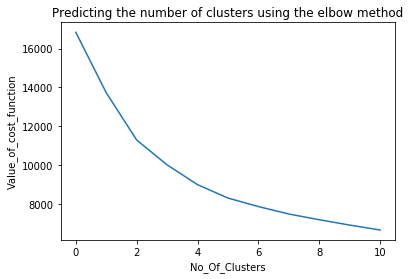

In [26]:
elb=[]
range_n_clusters=[2,3,4,5,6,7,8,9,10,11,12]
for num_clusters in range_n_clusters:
    kmeans=KMeans(n_clusters=num_clusters, max_iter=100)
    kmeans.fit(df_scaled)
    elb.append(kmeans.inertia_)
plt.plot(elb)
plt.title('Predicting the number of clusters using the elbow method')
plt.xlabel('No_Of_Clusters')
plt.ylabel('Value_of_cost_function')
plt.show()

In [44]:
%matplotlib notebook

Applying Kmeans clustering algo

In [28]:
kmeans=KMeans(n_clusters=5, max_iter=50)
kmeans.fit(df_scaled)
l=kmeans.labels_
print(kmeans.labels_)

[4 4 3 ... 4 4 2]


In [29]:
df_scaled['Cluster_Id']=l
df_scaled

,Tempo,Valence,energy,acousticness,duration_ms,instrumentalness,loudness,Cluster_Id
0,0.454842,0.239,0.200984,0.890562,0.260934,0.000000,0.368834,4
1,0.270445,0.160,0.128982,0.941767,0.338281,0.000005,0.356933,4
2,0.411715,0.559,0.588992,0.549197,0.287224,0.000000,0.767963,3
3,0.265552,0.122,0.285986,0.860442,0.383333,0.000000,0.674003,4
4,0.454413,0.441,0.211984,0.884538,0.457573,0.000022,0.486499,4
...,...,...,...,...,...,...,...,...
85735,0.523224,0.297,0.672993,0.143574,0.383697,0.000000,0.821742,0
85736,0.197827,0.890,0.017180,1.000000,0.097016,0.973000,0.024058,4
85737,0.171757,0.386,0.033080,1.000000,0.257677,0.961000,0.120737,4
85738,0.532915,0.211,0.517990,0.788153,0.371847,0.000000,0.699149,4


In [30]:
cluster_centers=kmeans.cluster_centers_
cluster_centers

array([[0.48615458, 0.33674732, 0.67101669, 0.13337969, 0.33466105,
        0.01281496, 0.72777069],
       [0.51158712, 0.38987067, 0.76753248, 0.09406488, 0.36616765,
        0.80013789, 0.67019485],
       [0.50257184, 0.73882722, 0.79645206, 0.10298363, 0.30411916,
        0.01019747, 0.76541706],
       [0.47029297, 0.68291707, 0.62291765, 0.53031379, 0.30155818,
        0.00894576, 0.71125529],
       [0.44595108, 0.30613368, 0.33441079, 0.76446308, 0.32563858,
        0.08340149, 0.58601689]])

In [45]:
a=cluster_centers[0]
a_attr_cent=a[3],a[1],a[2]

b=cluster_centers[1]
b_attr_cent=b[3],b[1],b[2]

c=cluster_centers[2]
c_attr_cent=c[3],c[1],c[2]

d=cluster_centers[3]
d_attr_cent=d[3],d[1],d[2]

e=cluster_centers[4]
e_attr_cent=e[3],e[1],e[2]

a_attr_cent

(0.1333796881792259, 0.33674731818548703, 0.671016689961512)

<IPython.core.display.Javascript object>


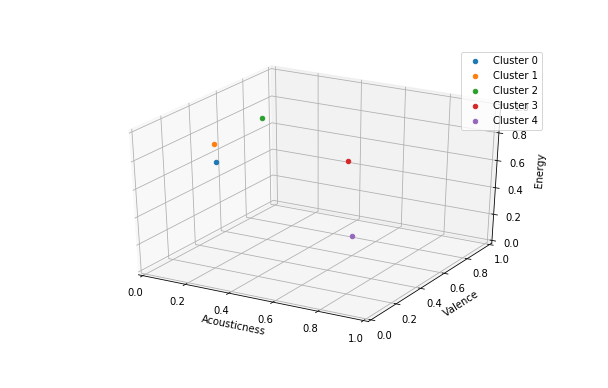

In [46]:
fig = plt.figure()
axis = fig.add_subplot(111, projection='3d')

axis.set_xlabel('Acousticness')
axis.set_ylabel('Valence')
axis.set_zlabel('Energy')

axis.scatter(a_attr_cent[0],a_attr_cent[1],a_attr_cent[2], label='Cluster 0')
axis.scatter(b_attr_cent[0],b_attr_cent[1],b_attr_cent[2], label='Cluster 1')
axis.scatter(c_attr_cent[0],c_attr_cent[1],c_attr_cent[2], label='Cluster 2')
axis.scatter(d_attr_cent[0],d_attr_cent[1],d_attr_cent[2], label='Cluster 3')
axis.scatter(e_attr_cent[0],e_attr_cent[1],e_attr_cent[2], label='Cluster 4')

plt.xlim(0,1)
plt.ylim(0,1)
axis.set_zlim(0,1)

axis.legend()
plt.show()

<IPython.core.display.Javascript object>


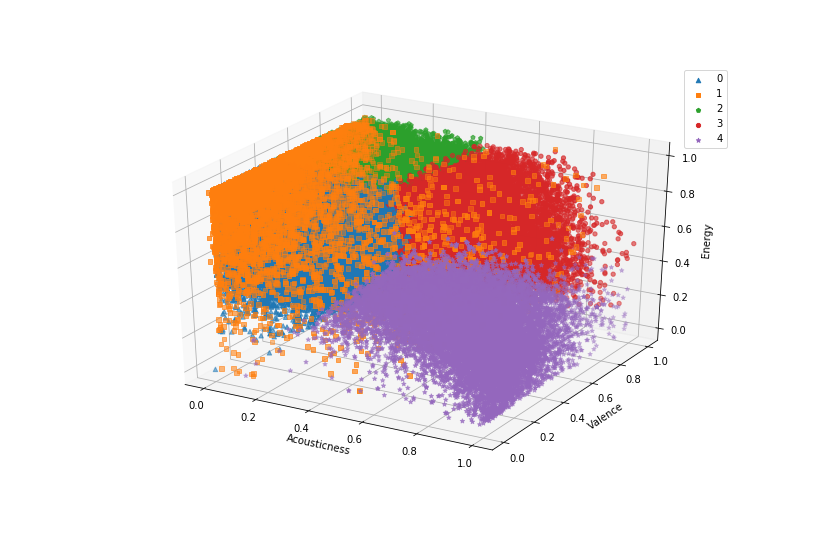

In [47]:
#tempo, instrumentalness, cluster_Id


fig = plt.figure()
axis = fig.add_subplot(111, projection='3d')

groups = df_scaled.groupby(by='Cluster_Id')

axis.set_xlabel('Acousticness')
axis.set_ylabel('Valence')
axis.set_zlabel('Energy')

shapes_dict = dict(zip(groups.indices.keys(),['^','s','p','8','*']))

for name, group in groups:
    axis.scatter(group.acousticness, group.Valence, group.energy, marker=shapes_dict[name], label=name)

axis.legend()
plt.show()

<IPython.core.display.Javascript object>


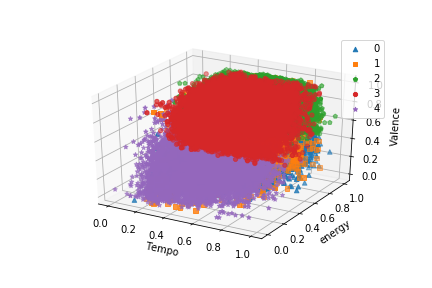

In [48]:
#tempo, instrumentalness, cluster_Id


fig = plt.figure()
axis = fig.add_subplot(111, projection='3d')

groups = df_scaled.groupby(by='Cluster_Id')

axis.set_xlabel('Tempo')
axis.set_ylabel('energy')
axis.set_zlabel('Valence')

shapes_dict = dict(zip(groups.indices.keys(),['^','s','p','8','*']))

for name, group in groups:
    axis.scatter(group.Tempo, group.energy, group.Valence, marker=shapes_dict[name], label=name)

axis.legend()
plt.show()

<IPython.core.display.Javascript object>


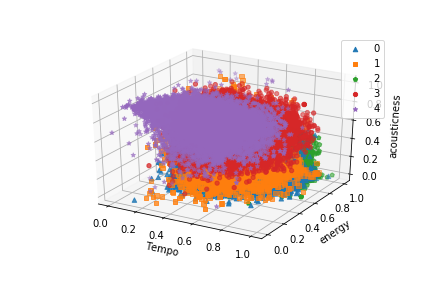

In [49]:

fig = plt.figure()
axis = fig.add_subplot(111, projection='3d')

groups = df_scaled.groupby(by='Cluster_Id')

axis.set_xlabel('Tempo')
axis.set_ylabel('energy')
axis.set_zlabel('acousticness')

shapes_dict = dict(zip(groups.indices.keys(),['^','s','p','8','*']))

for name, group in groups:
    axis.scatter(group.Tempo, group.energy, group.acousticness, marker=shapes_dict[name], label=name)

axis.legend()
plt.show()

<IPython.core.display.Javascript object>


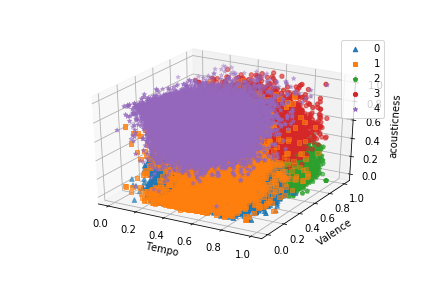

In [50]:
fig = plt.figure()
axis = fig.add_subplot(111, projection='3d')

groups = df_scaled.groupby(by='Cluster_Id')

axis.set_xlabel('Tempo')
axis.set_ylabel('Valence')
axis.set_zlabel('acousticness')

shapes_dict = dict(zip(groups.indices.keys(),['^','s','p','8','*']))

for name, group in groups:
    axis.scatter(group.Tempo, group.Valence, group.acousticness, marker=shapes_dict[name], label=name)

axis.legend()
plt.show()

Appending the clusters into the dataframe 

In [37]:
df_scaled['id'] = df_final['id']
df_scaled

,Tempo,Valence,energy,acousticness,duration_ms,instrumentalness,loudness,Cluster_Id,id
0,0.454842,0.239,0.200984,0.890562,0.260934,0.000000,0.368834,4,1hx7X9cMXHWJjknb9O6Ava
1,0.270445,0.160,0.128982,0.941767,0.338281,0.000005,0.356933,4,19oquvXf3bc65GSqtPYA5S
2,0.411715,0.559,0.588992,0.549197,0.287224,0.000000,0.767963,3,4ODWgs1CVAZKDbryEodjiz
3,0.265552,0.122,0.285986,0.860442,0.383333,0.000000,0.674003,4,0P5VfiSoLktD5N2nZDpQq0
4,0.454413,0.441,0.211984,0.884538,0.457573,0.000022,0.486499,4,55qyghODi24yaDgKBI6lx0
...,...,...,...,...,...,...,...,...,...
85735,0.523224,0.297,0.672993,0.143574,0.383697,0.000000,0.821742,0,4DSFl5u2ss5UpkT4rJNiHJ
85736,0.197827,0.890,0.017180,1.000000,0.097016,0.973000,0.024058,4,4DmjH02SMEc5Ge3O1yWHvB
85737,0.171757,0.386,0.033080,1.000000,0.257677,0.961000,0.120737,4,4riDB7r0brvb0lBmXUeP9i
85738,0.532915,0.211,0.517990,0.788153,0.371847,0.000000,0.699149,4,6Z3YNXEYbXjGBIbsfcvQvN


In [41]:
x = df_scaled[df_scaled['Cluster_Id'] == 3 ]
x = x.min()
x

Tempo               0.086456
Valence             0.206000
energy              0.006590
acousticness        0.061345
duration_ms         0.011904
instrumentalness    0.000000
loudness            0.240738
Cluster_Id          3.000000
dtype: float64

In [51]:
artists_name =[]
for i in df_scaled.id:
    artists_name.append(data[data['id'] == i].artists.tolist())
    
df_scaled['artists'] = artists_name
df_scaled

,Tempo,Valence,energy,acousticness,duration_ms,instrumentalness,loudness,Cluster_Id,id,artists
0,0.454842,0.239,0.200984,0.890562,0.260934,0.000000,0.368834,4,1hx7X9cMXHWJjknb9O6Ava,[Frank Sinatra]
1,0.270445,0.160,0.128982,0.941767,0.338281,0.000005,0.356933,4,19oquvXf3bc65GSqtPYA5S,[Frank Sinatra]
2,0.411715,0.559,0.588992,0.549197,0.287224,0.000000,0.767963,3,4ODWgs1CVAZKDbryEodjiz,[Frank Sinatra]
3,0.265552,0.122,0.285986,0.860442,0.383333,0.000000,0.674003,4,0P5VfiSoLktD5N2nZDpQq0,[Frank Sinatra]
4,0.454413,0.441,0.211984,0.884538,0.457573,0.000022,0.486499,4,55qyghODi24yaDgKBI6lx0,[Joni Mitchell]
...,...,...,...,...,...,...,...,...,...,...
85735,0.523224,0.297,0.672993,0.143574,0.383697,0.000000,0.821742,0,4DSFl5u2ss5UpkT4rJNiHJ,[Anna Maria Espinosa]
85736,0.197827,0.890,0.017180,1.000000,0.097016,0.973000,0.024058,4,4DmjH02SMEc5Ge3O1yWHvB,[One Voice]
85737,0.171757,0.386,0.033080,1.000000,0.257677,0.961000,0.120737,4,4riDB7r0brvb0lBmXUeP9i,[Mathilda Åström]
85738,0.532915,0.211,0.517990,0.788153,0.371847,0.000000,0.699149,4,6Z3YNXEYbXjGBIbsfcvQvN,[FO&O]


In [52]:
song =[]
for i in df_scaled.id:
    song.append(data[data['id'] == i].name_x.tolist())
    
df_scaled['song'] = song
df_scaled

,Tempo,Valence,energy,acousticness,duration_ms,instrumentalness,loudness,Cluster_Id,id,artists,song
0,0.454842,0.239,0.200984,0.890562,0.260934,0.000000,0.368834,4,1hx7X9cMXHWJjknb9O6Ava,[Frank Sinatra],[The September Of My Years - Live At The Sands...
1,0.270445,0.160,0.128982,0.941767,0.338281,0.000005,0.356933,4,19oquvXf3bc65GSqtPYA5S,[Frank Sinatra],[It Was A Very Good Year - Live At The Sands H...
2,0.411715,0.559,0.588992,0.549197,0.287224,0.000000,0.767963,3,4ODWgs1CVAZKDbryEodjiz,[Frank Sinatra],"[Theme From New York, New York]"
3,0.265552,0.122,0.285986,0.860442,0.383333,0.000000,0.674003,4,0P5VfiSoLktD5N2nZDpQq0,[Frank Sinatra],[It Was A Very Good Year]
4,0.454413,0.441,0.211984,0.884538,0.457573,0.000022,0.486499,4,55qyghODi24yaDgKBI6lx0,[Joni Mitchell],"[The Circle Game - Live at The 2nd Fret, Phila..."
...,...,...,...,...,...,...,...,...,...,...,...
85735,0.523224,0.297,0.672993,0.143574,0.383697,0.000000,0.821742,0,4DSFl5u2ss5UpkT4rJNiHJ,[Anna Maria Espinosa],[Alla ska sova för nu är det natt]
85736,0.197827,0.890,0.017180,1.000000,0.097016,0.973000,0.024058,4,4DmjH02SMEc5Ge3O1yWHvB,[One Voice],"[Frusen Själ - Från ""Frost""/Svenskt Original S..."
85737,0.171757,0.386,0.033080,1.000000,0.257677,0.961000,0.120737,4,4riDB7r0brvb0lBmXUeP9i,[Mathilda Åström],[Hjulen på bussen]
85738,0.532915,0.211,0.517990,0.788153,0.371847,0.000000,0.699149,4,6Z3YNXEYbXjGBIbsfcvQvN,[FO&O],[Build A Girl]


In [53]:
clust_0 = df_scaled[df_scaled['Cluster_Id']==0]  
clust_0.sample(30)

,Tempo,Valence,energy,acousticness,duration_ms,instrumentalness,loudness,Cluster_Id,id,artists,song
17189,0.628923,0.1400,0.497990,0.006637,0.418796,0.000000,0.740195,0,3D8khaPTTvjlWxSGZJ3Jh3,[Jul],[Ils m'ignorent]
63227,0.533418,0.3890,0.905998,0.075904,0.254190,0.000000,0.862467,0,6XJgsXXbMk8uuve1vMzf15,[Mister You],[30 Juin 2009]
76916,0.342872,0.3140,0.524990,0.054016,0.419358,0.000004,0.713801,0,0dy5NFDnx5fuZvE8ZXEX35,[Bonez MC],[Shotz Fired]
77496,0.681106,0.0485,0.643993,0.070181,0.453200,0.030900,0.699277,0,2NRB2bvU8B2jKa7bddokps,[Sierra Kidd],[Schon wieder high]
822,0.239450,0.5390,0.403988,0.219880,0.273442,0.000208,0.560177,0,4cWyMR0mjBuyS6pB3driwM,[David Bowie],[Black Country Rock - 2015 Remaster]
29117,0.168103,0.2970,0.385988,0.285141,0.370189,0.000000,0.661111,0,0AdpU8r6DXD7rNZ0YZnBOE,[Pino D'Angiò],[Una notte da impazzire]
74273,0.437944,0.1360,0.707994,0.415663,0.371115,0.023100,0.676819,0,1Z2izrSvleYnsvCviZEriC,[Mula B],[Fully Fendi]
77459,0.496370,0.3870,0.921998,0.001135,0.308947,0.000312,0.768923,0,4YLrDf8qrpEfGo8Btndj08,[MS MR],[Hurricane]
24600,0.469961,0.3720,0.681994,0.061847,0.276051,0.000000,0.732101,0,65mhesg9E1dT45P5DYX4wV,[Sech],[X Ti]
69347,0.496852,0.4490,0.897998,0.000063,0.424592,0.373000,0.816527,0,1UXanfz2RUi6lV49SUijCf,[Belo],[Vi Amor no Seu Olhar]


In [54]:
clust_1 = df_scaled[df_scaled['Cluster_Id']==1]  
clust_1.sample(30)

,Tempo,Valence,energy,acousticness,duration_ms,instrumentalness,loudness,Cluster_Id,id,artists,song
20069,0.565361,0.6070,0.989000,0.000090,0.055017,0.953,0.665846,1,798ahLNEcoFER7Vywg1FMT,[Calibre 50],[A La Antigüita]
60108,0.470019,0.7980,0.430988,0.067570,0.385544,0.546,0.698285,1,60xSgpwcHKHBxXqAomTIZF,[Ceza],[Kim Olduğunu Unut]
2707,0.547308,0.7350,0.984000,0.065361,0.287703,0.902,0.854885,1,NaN,[],[]
37681,0.491164,0.3640,0.915998,0.000053,0.404542,0.438,0.846119,1,3wxXMfRVUGtFvghEafgBjH,[A.B. Quintanilla III Y Los Kumbia Kings],[Te Quiero A Tí]
27191,0.682101,0.0886,0.458989,0.452811,0.579860,0.932,0.553042,1,6wj2FaVzZg62t1Lfdkksim,[Temple One],[Sahara Nights]
11048,0.734342,0.2240,0.436989,0.137550,0.644290,0.889,0.367010,1,5fP4sfaCpUi1kOB9Y4O4V1,[Shoes],[In My Arms Again]
69756,0.512288,0.9480,0.866997,0.051305,0.592233,0.614,0.693135,1,5xrgXIfSAsKKRYtYbza4bw,[G.U.T.S],[FLY OUT]
32210,0.682864,0.2460,0.942999,0.013454,0.228461,0.703,0.693710,1,7pWNm1wNjJRV0lKa61DSo0,[Hard Driver],[Crank It Up - Edit]
40996,0.474663,0.2880,0.603992,0.309237,0.687258,0.908,0.536791,1,6Qx0b9ArGdO5LCnG9UBdkO,[Adriel Favela],[Cuando los Necesité - Banda]
64979,0.475151,0.0330,0.892998,0.000201,0.378809,0.893,0.856005,1,00xlok82LYb4ByhaNnbajK,[Oxxxymiron],[Накануне]


In [55]:
clust_2 = df_scaled[df_scaled['Cluster_Id'] == 2]
clust_2

,Tempo,Valence,energy,acousticness,duration_ms,instrumentalness,loudness,Cluster_Id,id,artists,song
37,0.507538,0.564,0.857997,0.125502,0.241296,0.000006,0.802738,2,77Tkkebv42FGHxl1PHC1GO,[Jefferson Airplane],[Come Up The Years - Live 10.15.1966 Late Show...
45,0.501570,0.556,0.941999,0.090060,0.137305,0.000000,0.801139,2,6YfZaJBqeKtBWq2vqM6mdv,[Normie Rowe],[Ooh La La]
46,0.387985,0.940,0.738995,0.088755,0.280865,0.000001,0.730245,2,42A3B2pjAipXtpvfD8K3GZ,[Frankie Valli & The Four Seasons],[Working My Way Back to You]
47,0.501570,0.556,0.941999,0.090060,0.137305,0.000000,0.801139,2,6dCssZ3dlNqGqWHEckiewP,[Frankie Valli & The Four Seasons],"[December, 1963 (Oh, What a Night) - 2012 Coll..."
48,0.645551,0.567,0.790996,0.114458,0.285451,0.007880,0.704172,2,0fpqKUJC5NRRnb5AwuoeBF,[Frankie Valli & The Four Seasons],[Working My Way Back to You]
...,...,...,...,...,...,...,...,...,...,...,...
85695,0.332223,0.797,0.925998,0.045382,0.295958,0.000000,0.857189,2,4P7Nn5zvwXmLMCBOUgeJ3V,[Jens Hult],[Precis som du vill]
85705,0.522880,0.964,0.944999,0.051305,0.288437,0.000018,0.875488,2,0pM1qXcUs9lzLpDeR62HSo,[Ison & Fille],[Länge leve vi]
85713,0.532915,0.625,0.920998,0.138554,0.338238,0.000000,0.783927,2,73i7ey03q0T5JpXPyClwiz,[Nassim Al Fakir],[Om Sommarn]
85733,0.714081,0.640,0.567991,0.116466,0.241337,0.000000,0.734820,2,7jtpOERd746DHSyor5tSmx,[Anna Maria Espinosa],[Thula Sana]


In [56]:
clust_3 = df_scaled[df_scaled['Cluster_Id'] == 3]
clust_3

,Tempo,Valence,energy,acousticness,duration_ms,instrumentalness,loudness,Cluster_Id,id,artists,song
2,0.411715,0.559,0.588992,0.549197,0.287224,0.000000,0.767963,3,4ODWgs1CVAZKDbryEodjiz,[Frank Sinatra],"[Theme From New York, New York]"
31,0.543077,0.815,0.479989,0.871486,0.743803,0.779000,0.632030,3,NaN,[],[]
35,0.252726,0.654,0.471989,0.664659,0.472709,0.007480,0.678706,3,2MRb9AEURAkwnvHsxGMNkw,[Miles Davis],[Boplicity]
38,0.542891,0.953,0.528990,0.357430,0.239418,0.000000,0.622689,3,7l7vw9xdWTJLu0PQesQcaq,[The Yardbirds],[Happenings Ten Years Time Ago - Single A-Side]
41,0.356726,0.687,0.633993,0.281124,0.225200,0.000000,0.682289,3,5RmJqSP8jiIXocZX1DqJ49,[Carla Thomas],[B-A-B-Y]
...,...,...,...,...,...,...,...,...,...,...,...
85679,0.502004,0.879,0.747995,0.525100,0.264958,0.000000,0.686928,3,2J1FDNZmgNntWxARtd2xRy,[YOHIO],[Heartbreak Hotel]
85683,0.469553,0.772,0.722994,0.914659,0.350789,0.174000,0.604261,3,140fS3wKKBKrjbGR5EYMwu,[Det där bandet],[Om & om igen]
85684,0.289520,0.682,0.621992,0.586345,0.333502,0.000009,0.721671,3,3slik9WStKlRMguGSyDdCV,[Ralf Gyllenhammar],[Bed on Fire]
85686,0.584636,0.360,0.505990,0.498996,0.399574,0.000000,0.745185,3,36H4loxZp7YtvnsIsPYgRZ,[Barbados],[Världen utanför]


In [57]:
clust_4 = df_scaled[df_scaled['Cluster_Id']==4]  
clust_4.sample(30)

,Tempo,Valence,energy,acousticness,duration_ms,instrumentalness,loudness,Cluster_Id,id,artists,song
63825,0.470252,0.6460,0.251985,0.918675,0.179105,0.000000,0.511709,4,2T5ihhffxmrgqePASag6E2,[Kensington],[Bridges]
49391,0.281047,0.0922,0.162983,0.966867,0.198993,0.025700,0.508702,4,3mK9cwjeIAyTinfeUXrIU6,[Karen Mok],[執子之手]
83176,0.194798,0.1980,0.027080,0.987952,0.380966,0.927000,0.060369,4,5tEoaMG68JgH5RrsAOoden,[Kurokumo],[夜明けと蛍]
15179,0.271377,0.2280,0.110982,0.956827,0.343514,0.003420,0.463145,4,40fHWRL8bKcl5J4t4OKUiW,[Ariana Grande],[Why Try]
52979,0.598818,0.3630,0.409988,0.774096,0.352624,0.000000,0.703916,4,5L68Oq3yj6vzesEN9n3reV,[Shu-Bi-Dua],[Vuffeli-Vov]
85280,0.616172,0.3460,0.067181,0.941767,0.111402,0.000000,0.366274,4,3mz2XUXibVuKJ9rhxDOPl5,[kent],[Utan dina andetag]
20261,0.206252,0.7370,0.289986,0.858434,0.285826,0.000000,0.722951,4,5cwNC37WYaYJDNCxjNPOj6,[Los Plebes del Rancho de Ariel Camacho],[Por Enamorarme]
30057,0.311215,0.4040,0.647993,0.849398,0.348017,0.000003,0.834250,4,06VV1e6OgFMG2XSxsnRxxM,[Capo Plaza],[Giù da me]
65956,0.448403,0.5620,0.447989,0.811245,0.332256,0.000021,0.633022,4,13ivIwLlmicg1YnfBPZkna,[Платина],[Опиаты Круг]
58207,0.237734,0.0748,0.040081,0.990964,0.145777,0.934000,0.315663,4,23pZgY01lBlbwGyLIqZHt1,[Sabina Ddumba],[Effortless]


In [58]:
genre=[]
for row in df_scaled.Cluster_Id:
    if row == 0:
        genre.append('Chill')
    elif row == 1:
        genre.append('Energetic')
    elif row == 2:
        genre.append('Groovy')
    elif row == 3:
        genre.append('Ballad')
    else:
        genre.append('Pop')

df_scaled['Genre'] = genre
df_scaled

,Tempo,Valence,energy,acousticness,duration_ms,instrumentalness,loudness,Cluster_Id,id,artists,song,Genre
0,0.454842,0.239,0.200984,0.890562,0.260934,0.000000,0.368834,4,1hx7X9cMXHWJjknb9O6Ava,[Frank Sinatra],[The September Of My Years - Live At The Sands...,Pop
1,0.270445,0.160,0.128982,0.941767,0.338281,0.000005,0.356933,4,19oquvXf3bc65GSqtPYA5S,[Frank Sinatra],[It Was A Very Good Year - Live At The Sands H...,Pop
2,0.411715,0.559,0.588992,0.549197,0.287224,0.000000,0.767963,3,4ODWgs1CVAZKDbryEodjiz,[Frank Sinatra],"[Theme From New York, New York]",Ballad
3,0.265552,0.122,0.285986,0.860442,0.383333,0.000000,0.674003,4,0P5VfiSoLktD5N2nZDpQq0,[Frank Sinatra],[It Was A Very Good Year],Pop
4,0.454413,0.441,0.211984,0.884538,0.457573,0.000022,0.486499,4,55qyghODi24yaDgKBI6lx0,[Joni Mitchell],"[The Circle Game - Live at The 2nd Fret, Phila...",Pop
...,...,...,...,...,...,...,...,...,...,...,...,...
85735,0.523224,0.297,0.672993,0.143574,0.383697,0.000000,0.821742,0,4DSFl5u2ss5UpkT4rJNiHJ,[Anna Maria Espinosa],[Alla ska sova för nu är det natt],Chill
85736,0.197827,0.890,0.017180,1.000000,0.097016,0.973000,0.024058,4,4DmjH02SMEc5Ge3O1yWHvB,[One Voice],"[Frusen Själ - Från ""Frost""/Svenskt Original S...",Pop
85737,0.171757,0.386,0.033080,1.000000,0.257677,0.961000,0.120737,4,4riDB7r0brvb0lBmXUeP9i,[Mathilda Åström],[Hjulen på bussen],Pop
85738,0.532915,0.211,0.517990,0.788153,0.371847,0.000000,0.699149,4,6Z3YNXEYbXjGBIbsfcvQvN,[FO&O],[Build A Girl],Pop


In [59]:
df_scaled.sample(30)

,Tempo,Valence,energy,acousticness,duration_ms,instrumentalness,loudness,Cluster_Id,id,artists,song,Genre
2253,0.406345,0.7940,0.598992,0.215863,0.306206,0.000003,0.655640,2,7I7PdVkMOZuZswnMnSQlIV,[Paul Carrack],[I Think It's Going to Rain Today - Live at Lo...,Groovy
43001,0.843177,0.5450,0.912998,0.012550,0.331005,0.000062,0.774586,2,73Pwd0Wt43cEmLH8PsyTRy,[Cuatro Pesos de Propina],[La Fruta Permitida],Groovy
36432,0.321505,0.0787,0.437989,0.860442,0.079894,0.822000,0.269371,4,0zy4Q6nJPTqCrLcncBZ8v2,[Lito y Polaco],[Mundo Frio],Pop
48076,0.336550,0.1820,0.312986,0.867470,0.452862,0.000028,0.530488,4,4fJ8ZMIj7pI4SaRaUzdGIT,[Linda Chung],[我結婚了],Pop
45548,0.648798,0.3450,0.673993,0.259036,0.233831,0.000000,0.746945,0,2KCxwgB6IcUuFH4as39P4E,[Karolina Czarnecka],[Hera koka hasz LSD],Chill
5366,0.321632,0.6760,0.914998,0.005382,0.330028,0.000149,0.766428,2,3p1vxaIG6BDLnhJvyy2NNJ,[Maroon 5],[Girls Like You],Groovy
64768,0.523075,0.5890,0.524990,0.610442,0.181685,0.000072,0.636509,3,3K8Iec6qaIpcVgyWs0hOYq,[Gazo],[TCHIN 2X],Ballad
25682,0.892839,0.9630,0.768995,0.078012,0.315807,0.000000,0.761885,2,2Ge1fDDsnFbJynEpXhjmWD,[Toni Braxton],[Woman],Groovy
14702,0.480541,0.7340,0.792996,0.013655,0.342374,0.002210,0.764572,2,22t10FTx8y3pC5fjLuKJ8K,[Carlos Rivera],[Te Esperaba],Groovy
38414,0.259128,0.4130,0.627992,0.365462,0.354229,0.000000,0.764988,0,4UZdPR7auDwEnpPc5vHU7n,[Perotá Chingó],[Rie Chinito],Chill


In [60]:
df_scaled['artists'] = df_scaled['artists'].astype(str)

In [61]:
x= df_scaled[df_scaled['artists'] == "['Zakopower']"]
x

,Tempo,Valence,energy,acousticness,duration_ms,instrumentalness,loudness,Cluster_Id,id,artists,song,Genre
83819,0.575793,0.49,0.480989,0.76004,0.316703,0.0,0.64905,4,2kcQMkj0nztimTpqWlVrof,['Zakopower'],[Boso],Pop


In [62]:
x=data[data['artists'] == 'Zakopower']
x

,id,name_x,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,...,instrumentalness,liveness,valence,tempo,time_signature,release_year,followers,genres,name_y,artists_popularity
83886,2kcQMkj0nztimTpqWlVrof,Boso,43,223385,0,Zakopower,7ipF6efgwi4IXIGUWDVN4d,2011-05-16,0.719,0.657,...,0.000003,0.343,0.717,130.025,4,2011,12600.0,"['classic polish pop', 'polish pop']",Zakopower,33


In [63]:
df_scaled[df_scaled['artists'] == "['Dua Lipa']"]

,Tempo,Valence,energy,acousticness,duration_ms,instrumentalness,loudness,Cluster_Id,id,artists,song,Genre
18307,0.655772,0.4070,0.745995,0.002771,0.253700,0.000000,0.734468,0,1ixphys4A3NEXp6MDScfih,['Dua Lipa'],[Be the One],Chill
18308,0.655719,0.4900,0.719994,0.023695,0.334883,0.000000,0.766908,0,7kJlTKjNZVT26iwiDUVhRm,['Dua Lipa'],[Blow Your Mind (Mwah)],Chill
18309,0.655772,0.4070,0.745995,0.002771,0.253700,0.000000,0.734468,0,7wIYDzWW82O6Rc4vGuzjND,['Dua Lipa'],"[I'm Not the Only One - Live from Spotify, Lon...",Chill
18310,0.655772,0.4070,0.745995,0.002771,0.253700,0.000000,0.734468,0,2ekn2ttSfGqwhhate0LSR0,['Dua Lipa'],[New Rules],Chill
18311,0.655772,0.4070,0.745995,0.002771,0.253700,0.000000,0.734468,0,76cy1WJvNGJTj78UqeA5zr,['Dua Lipa'],[IDGAF],Chill
18312,0.655512,0.5730,0.653993,0.055221,0.319760,0.000000,0.714985,2,6WrI0LAC5M1Rw2MnX2ZvEg,['Dua Lipa'],[Don't Start Now],Groovy
18313,0.364018,0.2280,0.849997,0.029217,0.238059,0.000000,0.729413,0,3PfIrDoz19wz7qK7tYeu62,['Dua Lipa'],[Don't Start Now],Chill
18314,0.231734,0.0371,0.641993,0.425703,0.257717,0.000000,0.773946,0,017PF4Q3l4DBUiWoXk4OWT,['Dua Lipa'],[Break My Heart],Chill
18315,0.655555,0.2000,0.605992,0.222892,0.239177,0.000000,0.769051,0,39LLxExYz6ewLAcYrzQQyP,['Dua Lipa'],[Levitating],Chill
18316,0.522747,0.4870,0.610992,0.058434,0.300057,0.000000,0.777881,0,3AzjcOeAmA57TIOr9zF1ZW,['Dua Lipa'],[Physical],Chill


In [64]:
data[data['artists'] == 'Dua Lipa']

,id,name_x,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,...,instrumentalness,liveness,valence,tempo,time_signature,release_year,followers,genres,name_y,artists_popularity
18314,1ixphys4A3NEXp6MDScfih,Be the One,73,202915,0,Dua Lipa,6M2wZ9GZgrQXHCFfjv46we,2015-10-30,0.661,0.651,...,0.000013,0.0560,0.368,87.460,4,2015,24123468.0,"['dance pop', 'pop', 'uk pop']",Dua Lipa,95
18315,7kJlTKjNZVT26iwiDUVhRm,Blow Your Mind (Mwah),72,178583,1,Dua Lipa,6M2wZ9GZgrQXHCFfjv46we,2016-08-26,0.654,0.796,...,0.000000,0.0948,0.491,108.854,4,2016,24123468.0,"['dance pop', 'pop', 'uk pop']",Dua Lipa,95
18316,7wIYDzWW82O6Rc4vGuzjND,"I'm Not the Only One - Live from Spotify, London",68,195840,0,Dua Lipa,6M2wZ9GZgrQXHCFfjv46we,2016-07-08,0.455,0.265,...,0.000000,0.6850,0.324,176.036,4,2016,24123468.0,"['dance pop', 'pop', 'uk pop']",Dua Lipa,95
18317,2ekn2ttSfGqwhhate0LSR0,New Rules,82,209320,0,Dua Lipa,6M2wZ9GZgrQXHCFfjv46we,2017-06-02,0.762,0.700,...,0.000016,0.1530,0.608,116.073,4,2017,24123468.0,"['dance pop', 'pop', 'uk pop']",Dua Lipa,95
18318,76cy1WJvNGJTj78UqeA5zr,IDGAF,81,217947,1,Dua Lipa,6M2wZ9GZgrQXHCFfjv46we,2017-06-02,0.836,0.544,...,0.000000,0.0824,0.510,97.028,4,2017,24123468.0,"['dance pop', 'pop', 'uk pop']",Dua Lipa,95
18319,6WrI0LAC5M1Rw2MnX2ZvEg,Don't Start Now,86,183290,0,Dua Lipa,6M2wZ9GZgrQXHCFfjv46we,2019-10-31,0.794,0.793,...,0.000000,0.0952,0.677,123.941,4,2019,24123468.0,"['dance pop', 'pop', 'uk pop']",Dua Lipa,95
18320,3PfIrDoz19wz7qK7tYeu62,Don't Start Now,85,183290,0,Dua Lipa,6M2wZ9GZgrQXHCFfjv46we,2020-03-27,0.793,0.793,...,0.000000,0.0951,0.679,123.950,4,2020,24123468.0,"['dance pop', 'pop', 'uk pop']",Dua Lipa,95
18321,017PF4Q3l4DBUiWoXk4OWT,Break My Heart,84,221820,0,Dua Lipa,6M2wZ9GZgrQXHCFfjv46we,2020-03-27,0.730,0.729,...,0.000001,0.3490,0.467,113.013,4,2020,24123468.0,"['dance pop', 'pop', 'uk pop']",Dua Lipa,95
18322,39LLxExYz6ewLAcYrzQQyP,Levitating,82,203808,0,Dua Lipa,6M2wZ9GZgrQXHCFfjv46we,2020-03-27,0.695,0.884,...,0.000000,0.2130,0.914,103.014,4,2020,24123468.0,"['dance pop', 'pop', 'uk pop']",Dua Lipa,95
18323,3AzjcOeAmA57TIOr9zF1ZW,Physical,79,193829,0,Dua Lipa,6M2wZ9GZgrQXHCFfjv46we,2020-03-27,0.647,0.844,...,0.000658,0.1020,0.746,146.967,4,2020,24123468.0,"['dance pop', 'pop', 'uk pop']",Dua Lipa,95


In [65]:
df_scaled[df_scaled['artists'] == "['Thundercat']"]

,Tempo,Valence,energy,acousticness,duration_ms,instrumentalness,loudness,Cluster_Id,id,artists,song,Genre
21487,0.437960,0.451,0.416988,0.391566,0.243756,0.0,0.719816,3,7CH99b2i1TXS5P8UUyWtnM,['Thundercat'],[Them Changes],Ballad
21488,0.353284,0.396,0.465989,0.459839,0.253846,0.0,0.718408,3,1c5CllrZr45UBhWpIqM332,['Thundercat'],[Funny Thing],Ballad


In [66]:
data[data['artists'] == 'Thundercat']

,id,name_x,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,...,instrumentalness,liveness,valence,tempo,time_signature,release_year,followers,genres,name_y,artists_popularity
21505,7CH99b2i1TXS5P8UUyWtnM,Them Changes,74,188454,0,Thundercat,4frXpPxQQZwbCu3eTGnZEw,2017-02-24,0.657,0.562,...,0.00143,0.101,0.704,81.657,4,2017,721390.0,"['afrofuturism', 'hip hop', 'indie soul']",Thundercat,73
21506,1c5CllrZr45UBhWpIqM332,Funny Thing,77,116630,0,Thundercat,4frXpPxQQZwbCu3eTGnZEw,2020-04-03,0.586,0.893,...,0.64200,0.212,0.650,140.023,3,2020,721390.0,"['afrofuturism', 'hip hop', 'indie soul']",Thundercat,73


In [67]:
df_scaled[df_scaled['artists'] == "['Good Charlotte']"]

,Tempo,Valence,energy,acousticness,duration_ms,instrumentalness,loudness,Cluster_Id,id,artists,song,Genre
66525,0.247949,0.425,0.671993,0.238956,0.358010,0.000000,0.762941,0,2wcDfk3TfQg3Jv8gEoTim7,['Good Charlotte'],[I Just Wanna Live],Chill
66526,0.448503,0.282,0.937999,0.021285,0.273589,0.000000,0.820622,0,3cO8w5kGXDdwQywhiX0G8J,['Good Charlotte'],[Last Night],Chill
66527,0.332101,0.686,0.855997,0.007661,0.311710,0.000019,0.784087,2,0AYw1CBLLNu0umIuCoq77M,['Good Charlotte'],[Like It's Her Birthday],Groovy
66528,0.639038,0.495,0.721994,0.068173,0.311344,0.000000,0.782904,0,5wJ0BL1beppAHQO3DtlEqh,['Good Charlotte'],[Sex On The Radio],Chill


In [68]:
data[data['artists'] == 'Good Charlotte']

,id,name_x,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,...,instrumentalness,liveness,valence,tempo,time_signature,release_year,followers,genres,name_y,artists_popularity
66587,2wcDfk3TfQg3Jv8gEoTim7,I Just Wanna Live,54,165947,0,Good Charlotte,5aYyPjAsLj7UzANzdupwnS,2010-11-12,0.804,0.832,...,0.0,0.1070,0.900,111.023,4,2010,1989728.0,"['alternative metal', 'pop punk']",Good Charlotte,71
66588,3cO8w5kGXDdwQywhiX0G8J,Last Night,50,220827,0,Good Charlotte,5aYyPjAsLj7UzANzdupwnS,2010-01-01,0.641,0.849,...,0.0,0.0418,0.730,128.063,4,2010,1989728.0,"['alternative metal', 'pop punk']",Good Charlotte,71
66589,0AYw1CBLLNu0umIuCoq77M,Like It's Her Birthday,51,210507,0,Good Charlotte,5aYyPjAsLj7UzANzdupwnS,2010-01-01,0.592,0.868,...,0.0,0.1440,0.815,109.985,4,2010,1989728.0,"['alternative metal', 'pop punk']",Good Charlotte,71
66590,5wJ0BL1beppAHQO3DtlEqh,Sex On The Radio,46,196587,0,Good Charlotte,5aYyPjAsLj7UzANzdupwnS,2010-01-01,0.548,0.815,...,0.0,0.0175,0.867,151.970,4,2010,1989728.0,"['alternative metal', 'pop punk']",Good Charlotte,71


In [69]:
df_scaled[df_scaled['artists'] == "['Flume']"]

,Tempo,Valence,energy,acousticness,duration_ms,instrumentalness,loudness,Cluster_Id,id,artists,song,Genre
29394,0.628187,0.329,0.971999,0.053715,0.262977,0.000919,0.855301,0,7e3tOlmiPgelgliAQPZYZd,['Flume'],[Holdin On],Chill
29395,0.628187,0.329,0.971999,0.053715,0.262977,0.000919,0.855301,0,3ibA9LHADI12A3FHpeRx7Q,['Flume'],[Ezra],Chill
29396,0.630396,0.342,0.966999,0.063855,0.262769,0.001550,0.855397,0,4s5652m7A8iuDQsZ0UWNcO,['Flume'],[Holdin On],Chill
29397,0.289938,0.417,0.361987,0.454819,0.261101,0.000000,0.567567,4,3ohupB1Wm1Cvcyre7rtS9p,['Flume'],[Holdin On],Pop


In [70]:
data[data['artists'] == 'Flume']

,id,name_x,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,...,instrumentalness,liveness,valence,tempo,time_signature,release_year,followers,genres,name_y,artists_popularity
29420,7e3tOlmiPgelgliAQPZYZd,Holdin On,59,154414,0,Flume,6nxWCVXbOlEVRexSbLsTer,2012-11-09,0.430,0.436,...,0.000000,0.128,0.217,90.053,4,2012,2157188.0,"['australian dance', 'australian electropop', ...",Flume,76
29421,3ibA9LHADI12A3FHpeRx7Q,Ezra,45,217188,0,Flume,6nxWCVXbOlEVRexSbLsTer,2012-11-09,0.582,0.544,...,0.006980,0.173,0.398,89.876,4,2012,2157188.0,"['australian dance', 'australian electropop', ...",Flume,76
29422,4s5652m7A8iuDQsZ0UWNcO,Holdin On,55,154414,0,Flume,6nxWCVXbOlEVRexSbLsTer,2012-11-12,0.433,0.435,...,0.000002,0.128,0.216,90.036,4,2012,2157188.0,"['australian dance', 'australian electropop', ...",Flume,76
29423,3ohupB1Wm1Cvcyre7rtS9p,Holdin On,55,154414,0,Flume,6nxWCVXbOlEVRexSbLsTer,2012-11-09,0.430,0.436,...,0.000000,0.128,0.217,90.053,4,2012,2157188.0,"['australian dance', 'australian electropop', ...",Flume,76
